# Notebook final — Estimativa do geoide com dados reais

Este notebook usa os arquivos reais na pasta:

```text
geodesy_input/
```

com três colunas:

```text
longitude   latitude   valor
```

Arquivos esperados:

```text
geodesy_input/topografia.txt
geodesy_input/disturbio.txt
geodesy_input/geoide.txt
```

O fluxo executado é:

1. leitura dos arquivos reais;
2. conversão para grade regular;
3. verificação de compatibilidade das grades;
4. plotagem da topografia, distúrbio e geoide verdadeiro;
5. estimativa do geoide a partir do distúrbio usando `stokes.planar_stokes_fft_approx`;
6. calibração linear opcional do geoide estimado;
7. comparação com o geoide verdadeiro;
8. cálculo de métricas;
9. geração de mapas e histogramas;
10. salvamento dos resultados em `geodesy_results/`.

Antes de rodar, confirme que o arquivo corrigido `stokes.py` já foi colocado dentro da pasta `geodesy/`.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path
import importlib
import inspect

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import io
from geodesy import stokes

# Recarrega o módulo stokes para garantir que a versão corrigida está sendo usada.
importlib.reload(stokes)

print("Versão do pacote geodesy:", geodesy.__version__)
print("Arquivo stokes.py usado:", stokes.__file__)
print("Assinatura da função planar_stokes_fft_approx:")
print(inspect.signature(stokes.planar_stokes_fft_approx))

input_dir = Path("geodesy_input")
output_dir = Path("geodesy_results")
output_dir.mkdir(exist_ok=True)

topo_file = input_dir / "topografia.txt"
dist_file = input_dir / "disturbio.txt"
geoide_file = input_dir / "geoide.txt"

print("\nArquivos esperados:")
print(topo_file)
print(dist_file)
print(geoide_file)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0
Arquivo stokes.py usado: C:\Users\Usuario\Python_Notebooks\python-modeling\geophysics\geodesy\stokes.py
Assinatura da função planar_stokes_fft_approx:
(gravity_anomaly_mgal, dx, dy, gamma=9.7803253359)

Arquivos esperados:
geodesy_input\topografia.txt
geodesy_input\disturbio.txt
geodesy_input\geoide.txt


## 1. Verificação dos arquivos de entrada


In [2]:
# ============================================================
# 1. VERIFICAR SE OS ARQUIVOS EXISTEM
# ============================================================

arquivos = [topo_file, dist_file, geoide_file]

for arq in arquivos:
    print(arq, "->", "existe" if arq.exists() else "não encontrado")

if not all(arq.exists() for arq in arquivos):
    raise FileNotFoundError(
        "Um ou mais arquivos não foram encontrados. "
        "Confira se topografia.txt, disturbio.txt e geoide.txt estão em geodesy_input/."
    )


geodesy_input\topografia.txt -> existe
geodesy_input\disturbio.txt -> existe
geodesy_input\geoide.txt -> existe


## 2. Leitura dos arquivos reais


In [3]:
# ============================================================
# 2. LEITURA DOS DADOS
# ============================================================
# Se seus arquivos tiverem cabeçalho, altere skiprows=0 para skiprows=1.

skiprows = 0

lon_topo, lat_topo, topo = io.read_lon_lat_value(topo_file, skiprows=skiprows)
lon_dist, lat_dist, disturbio = io.read_lon_lat_value(dist_file, skiprows=skiprows)
lon_geo, lat_geo, geoide_true = io.read_lon_lat_value(geoide_file, skiprows=skiprows)

print("Topografia:")
print("  pontos:", len(topo))
print("  lon min/max:", lon_topo.min(), lon_topo.max())
print("  lat min/max:", lat_topo.min(), lat_topo.max())
print("  valor min/max:", np.nanmin(topo), np.nanmax(topo))

print("\nDistúrbio:")
print("  pontos:", len(disturbio))
print("  lon min/max:", lon_dist.min(), lon_dist.max())
print("  lat min/max:", lat_dist.min(), lat_dist.max())
print("  valor min/max:", np.nanmin(disturbio), np.nanmax(disturbio))

print("\nGeoide verdadeiro:")
print("  pontos:", len(geoide_true))
print("  lon min/max:", lon_geo.min(), lon_geo.max())
print("  lat min/max:", lat_geo.min(), lat_geo.max())
print("  valor min/max:", np.nanmin(geoide_true), np.nanmax(geoide_true))


Topografia:
  pontos: 60501
  lon min/max: -50.0 -40.0
  lat min/max: -10.0 5.0
  valor min/max: -4969.59199 962.52968

Distúrbio:
  pontos: 60501
  lon min/max: -50.0 -40.0
  lat min/max: -10.0 5.0
  valor min/max: -98.51987 82.99106

Geoide verdadeiro:
  pontos: 60501
  lon min/max: -50.0 -40.0
  lat min/max: -10.0 5.0
  valor min/max: -36.51482 -9.81037


## 3. Verificação de grade regular


In [4]:
# ============================================================
# 3. VERIFICAR GRADE REGULAR
# ============================================================

reg_topo, nx_topo, ny_topo = io.check_regular_grid(lon_topo, lat_topo)
reg_dist, nx_dist, ny_dist = io.check_regular_grid(lon_dist, lat_dist)
reg_geo, nx_geo, ny_geo = io.check_regular_grid(lon_geo, lat_geo)

print("Topografia regular?", reg_topo, "| nx, ny =", nx_topo, ny_topo)
print("Distúrbio regular?", reg_dist, "| nx, ny =", nx_dist, ny_dist)
print("Geoide regular?", reg_geo, "| nx, ny =", nx_geo, ny_geo)

if not (reg_topo and reg_dist and reg_geo):
    raise ValueError(
        "Pelo menos um dos arquivos não forma grade regular completa. "
        "Será necessário interpolar antes de aplicar este notebook."
    )


Topografia regular? True | nx, ny = 201 301
Distúrbio regular? True | nx, ny = 201 301
Geoide regular? True | nx, ny = 201 301


## 4. Conversão para grade


In [5]:
# ============================================================
# 4. CONVERSÃO XYZ -> GRID
# ============================================================

LON_TOPO, LAT_TOPO, TOPO = io.xyz_to_grid(lon_topo, lat_topo, topo)
LON_DIST, LAT_DIST, DIST = io.xyz_to_grid(lon_dist, lat_dist, disturbio)
LON_GEO, LAT_GEO, GEOIDE_TRUE = io.xyz_to_grid(lon_geo, lat_geo, geoide_true)

print("Shape TOPO:", TOPO.shape)
print("Shape DIST:", DIST.shape)
print("Shape GEOIDE_TRUE:", GEOIDE_TRUE.shape)

print("\nNaN TOPO:", np.isnan(TOPO).sum())
print("NaN DIST:", np.isnan(DIST).sum())
print("NaN GEOIDE_TRUE:", np.isnan(GEOIDE_TRUE).sum())

same_shape = (TOPO.shape == DIST.shape == GEOIDE_TRUE.shape)
same_lon = np.allclose(LON_TOPO, LON_DIST) and np.allclose(LON_TOPO, LON_GEO)
same_lat = np.allclose(LAT_TOPO, LAT_DIST) and np.allclose(LAT_TOPO, LAT_GEO)

print("\nMesmo shape?", same_shape)
print("Mesma longitude?", same_lon)
print("Mesma latitude?", same_lat)

if not (same_shape and same_lon and same_lat):
    raise ValueError(
        "As grades não são compatíveis. "
        "Confira se os três arquivos possuem a mesma malha de longitude e latitude."
    )

LON = LON_TOPO
LAT = LAT_TOPO


Shape TOPO: (301, 201)
Shape DIST: (301, 201)
Shape GEOIDE_TRUE: (301, 201)

NaN TOPO: 0
NaN DIST: 0
NaN GEOIDE_TRUE: 0

Mesmo shape? True
Mesma longitude? True
Mesma latitude? True


## 5. Plot dos dados reais de entrada


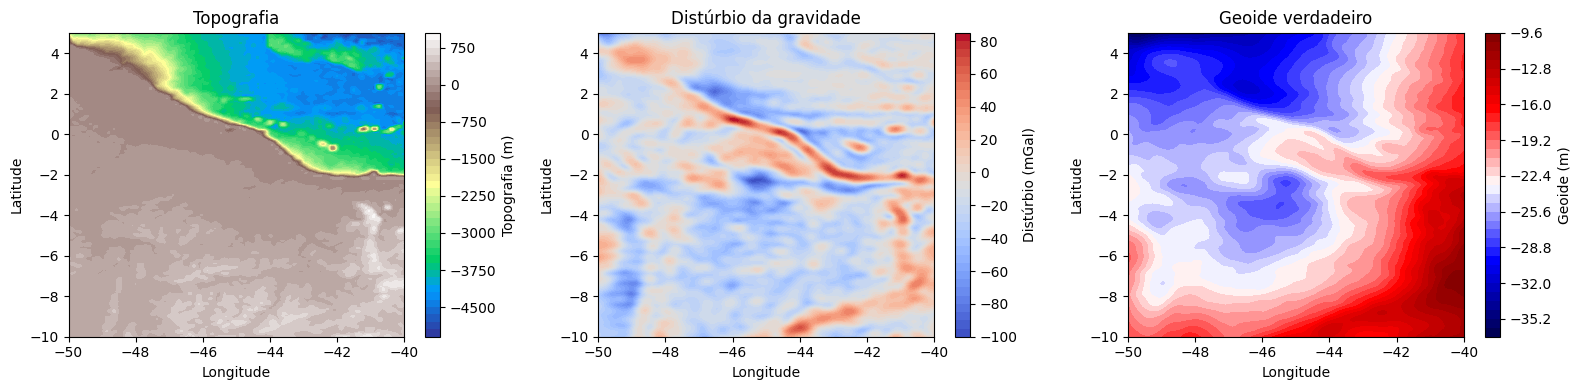

In [8]:
# ============================================================
# 5. PAINEL DOS DADOS REAIS
# ============================================================

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, TOPO, levels=40, cmap="terrain")
plt.colorbar(c1, label="Topografia (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Topografia")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, DIST, levels=40, cmap="coolwarm")
plt.colorbar(c2, label="Distúrbio (mGal)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distúrbio da gravidade")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, GEOIDE_TRUE, levels=40, cmap="seismic")
plt.colorbar(c3, label="Geoide (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geoide verdadeiro")

plt.tight_layout()
plt.savefig(output_dir / "01_dados_reais_entrada.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Estimativa do geoide a partir do distúrbio de gravidade


In [9]:
# ============================================================
# 6. ESTIMATIVA DO GEOIDE POR FFT/STOKES PLANAR
# ============================================================

# Espaçamentos médios em graus
lon_unique = np.unique(LON[0, :])
lat_unique = np.unique(LAT[:, 0])

dlon_deg = np.nanmedian(np.abs(np.diff(lon_unique)))
dlat_deg = np.nanmedian(np.abs(np.diff(lat_unique)))

lat_mean = np.nanmean(LAT)

# Conversão aproximada grau -> metro
dx = dlon_deg * 111000.0 * np.cos(np.deg2rad(lat_mean))
dy = dlat_deg * 111000.0

print("dlon_deg:", dlon_deg)
print("dlat_deg:", dlat_deg)
print("lat_mean:", lat_mean)
print("dx:", dx, "m")
print("dy:", dy, "m")

# Remove a média do distúrbio para evitar dominante de comprimento de onda infinito
DIST_ZERO_MEAN = DIST - np.nanmean(DIST)

GEOIDE_EST = stokes.planar_stokes_fft_approx(
    DIST_ZERO_MEAN,
    dx=dx,
    dy=dy
)

print("Geoide estimado min/max:", np.nanmin(GEOIDE_EST), np.nanmax(GEOIDE_EST))


dlon_deg: 0.04999999999999716
dlat_deg: 0.04999999999999982
lat_mean: -2.4999999999999996
dx: 5544.717629778996 m
dy: 5549.99999999998 m
Geoide estimado min/max: -4.658944771261707 3.9071512797664876


## 7. Calibração linear do geoide estimado


In [10]:
# ============================================================
# 7. CALIBRAÇÃO LINEAR
# ============================================================
# Ajusta: GEOIDE_TRUE ≈ a * GEOIDE_EST + b

mask = (
    np.isfinite(GEOIDE_TRUE)
    & np.isfinite(GEOIDE_EST)
)

A = np.column_stack([
    GEOIDE_EST[mask].ravel(),
    np.ones(np.sum(mask))
])

coef, _, _, _ = np.linalg.lstsq(A, GEOIDE_TRUE[mask].ravel(), rcond=None)

a, b = coef

GEOIDE_CAL = a * GEOIDE_EST + b

print("Coeficiente a:", a)
print("Coeficiente b:", b)
print("Geoide calibrado min/max:", np.nanmin(GEOIDE_CAL), np.nanmax(GEOIDE_CAL))


Coeficiente a: 1.0559353931544868
Coeficiente b: -22.747272134179568
Geoide calibrado min/max: -27.666816812906838 -18.621572811465285


## 8. Resíduos e métricas


In [11]:
# ============================================================
# 8. MÉTRICAS DE ERRO
# ============================================================

RES_RAW = GEOIDE_TRUE - GEOIDE_EST
RES_CAL = GEOIDE_TRUE - GEOIDE_CAL

def metrics(residual, name):
    valid = np.isfinite(residual)
    rmse = np.sqrt(np.nanmean(residual[valid]**2))
    mae = np.nanmean(np.abs(residual[valid]))
    mean = np.nanmean(residual[valid])
    std = np.nanstd(residual[valid])
    max_abs = np.nanmax(np.abs(residual[valid]))

    print(name)
    print("-" * len(name))
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("Média:", mean)
    print("Desvio padrão:", std)
    print("Erro máximo absoluto:", max_abs)
    print()

metrics(RES_RAW, "Erro sem calibração")
metrics(RES_CAL, "Erro com calibração linear")


Erro sem calibração
-------------------
RMSE: 23.17550943863969
MAE: 22.747272134179596
Média: -22.747272134179596
Desvio padrão: 4.434619284003262
Erro máximo absoluto: 35.90289370986737

Erro com calibração linear
--------------------------
RMSE: 4.43358009774437
MAE: 3.594341579627803
Média: -3.259094086781555e-14
Desvio padrão: 4.43358009774437
Erro máximo absoluto: 13.1393563302253



## 9. Painel principal de comparação


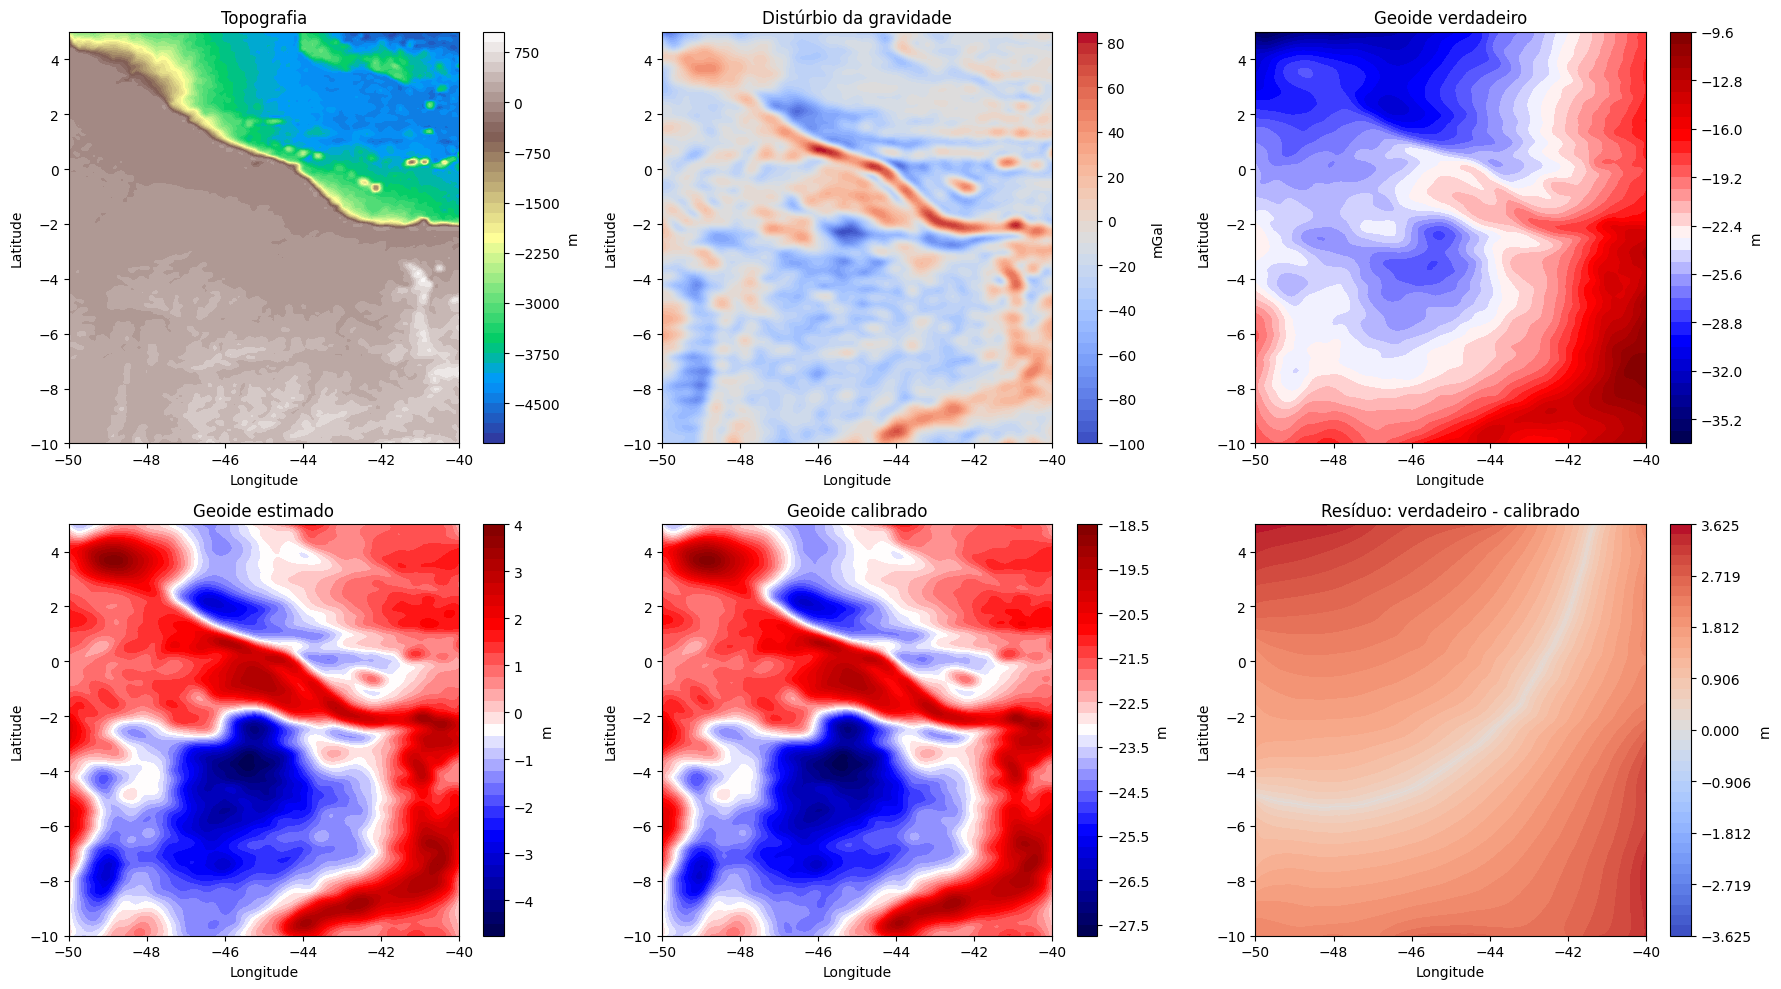

In [14]:
# ============================================================
# 9. PAINEL PRINCIPAL
# ============================================================

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
c1 = plt.contourf(LON, LAT, TOPO, levels=40, cmap="terrain")
plt.colorbar(c1, label="m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Topografia")

plt.subplot(2, 3, 2)
c2 = plt.contourf(LON, LAT, DIST, levels=40, cmap="coolwarm")
plt.colorbar(c2, label="mGal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distúrbio da gravidade")

plt.subplot(2, 3, 3)
c3 = plt.contourf(LON, LAT, GEOIDE_TRUE, levels=40, cmap="seismic")
plt.colorbar(c3, label="m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geoide verdadeiro")

plt.subplot(2, 3, 4)
c4 = plt.contourf(LON, LAT, GEOIDE_EST, levels=40, cmap="seismic")
plt.colorbar(c4, label="m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geoide estimado")

plt.subplot(2, 3, 5)
c5 = plt.contourf(LON, LAT, GEOIDE_CAL, levels=40, cmap="seismic")
plt.colorbar(c5, label="m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geoide calibrado")

plt.subplot(2, 3, 6)
vmax = np.nanmax(np.abs(RES_CAL))
c6 = plt.contourf(
    LON,
    LAT,
    RES_CAL,
    levels=np.linspace(-vmax, vmax, 41),
    cmap="coolwarm"
)
plt.colorbar(c6, label="m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Resíduo: verdadeiro - calibrado")

plt.tight_layout()
plt.savefig(output_dir / "02_painel_geoide_estimado.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Histogramas dos resíduos


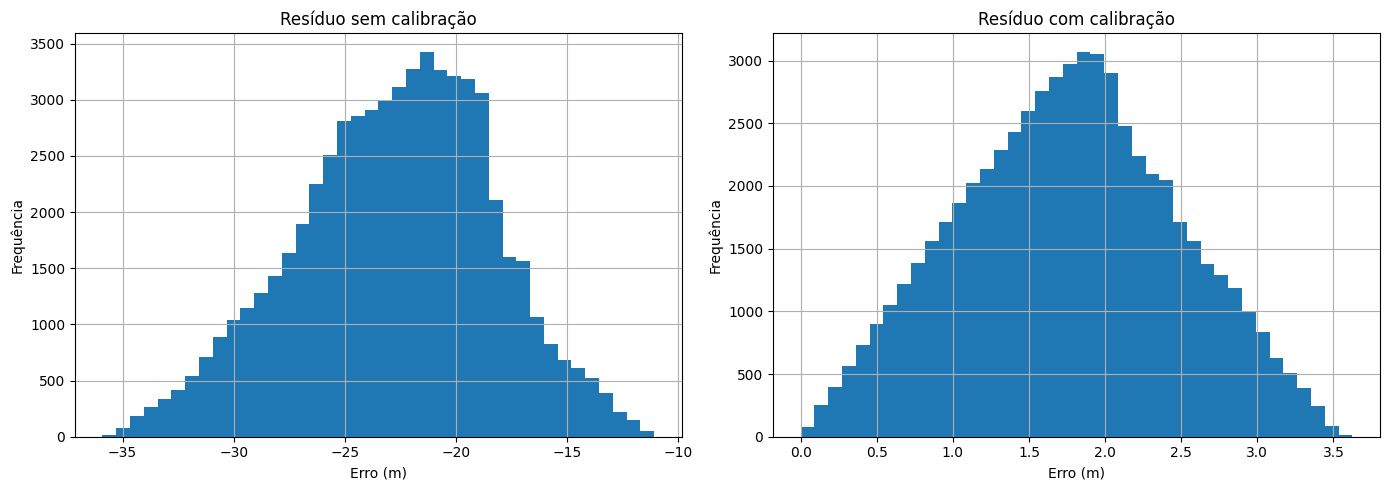

In [15]:
# ============================================================
# 10. HISTOGRAMAS
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(RES_RAW[np.isfinite(RES_RAW)].ravel(), bins=40)
plt.xlabel("Erro (m)")
plt.ylabel("Frequência")
plt.title("Resíduo sem calibração")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(RES_CAL[np.isfinite(RES_CAL)].ravel(), bins=40)
plt.xlabel("Erro (m)")
plt.ylabel("Frequência")
plt.title("Resíduo com calibração")
plt.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "03_histogramas_residuos.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Perfil central para comparação


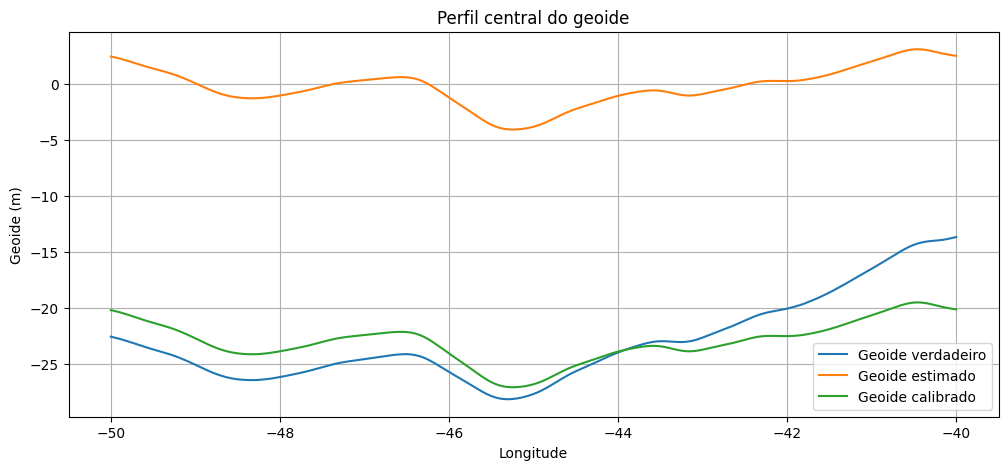

In [16]:
# ============================================================
# 11. PERFIL CENTRAL
# ============================================================

iy = GEOIDE_TRUE.shape[0] // 2

plt.figure(figsize=(12, 5))
plt.plot(LON[iy, :], GEOIDE_TRUE[iy, :], label="Geoide verdadeiro")
plt.plot(LON[iy, :], GEOIDE_EST[iy, :], label="Geoide estimado")
plt.plot(LON[iy, :], GEOIDE_CAL[iy, :], label="Geoide calibrado")
plt.xlabel("Longitude")
plt.ylabel("Geoide (m)")
plt.title("Perfil central do geoide")
plt.legend()
plt.grid(True)
plt.savefig(output_dir / "04_perfil_central_geoide.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Dispersão: geoide verdadeiro vs estimado


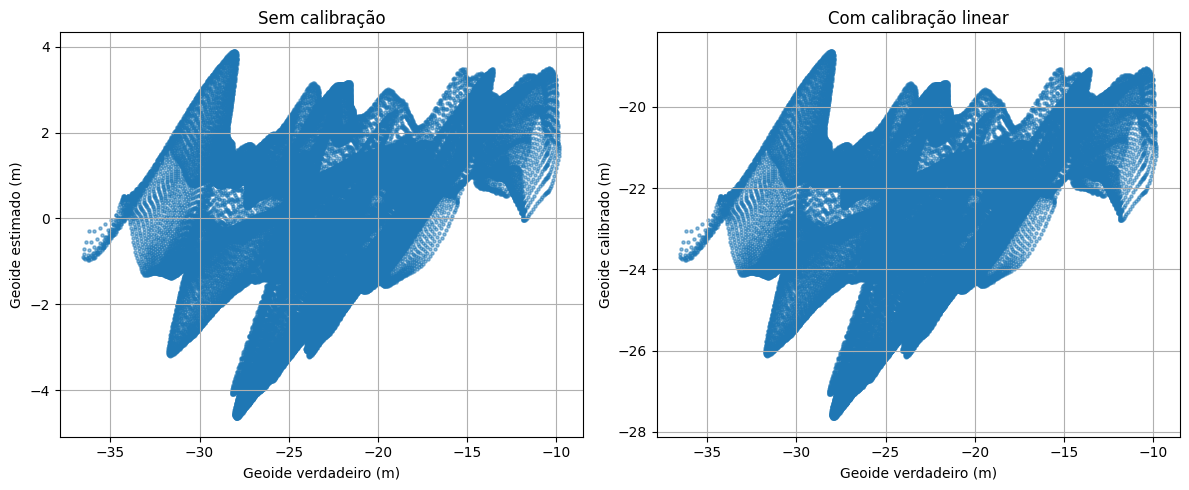

In [17]:
# ============================================================
# 12. SCATTER
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(GEOIDE_TRUE[mask], GEOIDE_EST[mask], s=5, alpha=0.5)
plt.xlabel("Geoide verdadeiro (m)")
plt.ylabel("Geoide estimado (m)")
plt.title("Sem calibração")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(GEOIDE_TRUE[mask], GEOIDE_CAL[mask], s=5, alpha=0.5)
plt.xlabel("Geoide verdadeiro (m)")
plt.ylabel("Geoide calibrado (m)")
plt.title("Com calibração linear")
plt.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "05_scatter_geoide.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Salvar resultados em arquivos `.txt`


In [18]:
# ============================================================
# 13. SALVAR RESULTADOS
# ============================================================

x_out, y_out, n_est_out = io.grid_to_xyz(LON, LAT, GEOIDE_EST)
_, _, n_cal_out = io.grid_to_xyz(LON, LAT, GEOIDE_CAL)
_, _, res_cal_out = io.grid_to_xyz(LON, LAT, RES_CAL)

io.write_xyz_file(
    output_dir / "geoide_estimado.txt",
    x_out,
    y_out,
    n_est_out,
    header="longitude latitude geoide_estimado",
    fmt="%.10f"
)

io.write_xyz_file(
    output_dir / "geoide_calibrado.txt",
    x_out,
    y_out,
    n_cal_out,
    header="longitude latitude geoide_calibrado",
    fmt="%.10f"
)

io.write_xyz_file(
    output_dir / "residuo_geoide_calibrado.txt",
    x_out,
    y_out,
    res_cal_out,
    header="longitude latitude residuo",
    fmt="%.10f"
)

print("Arquivos salvos em:", output_dir)


Arquivos salvos em: geodesy_results


## 14. Mapa Cartopy opcional


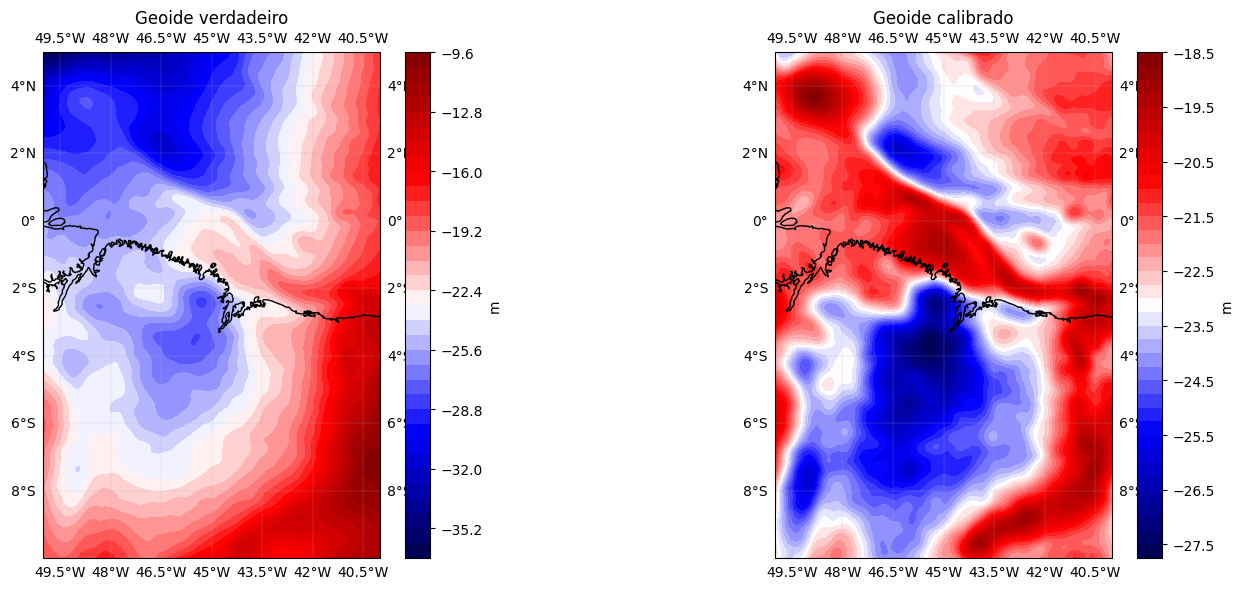

In [20]:
# ============================================================
# 14. MAPA COM CARTOPY OPCIONAL
# ============================================================
# Esta célula só roda se Cartopy estiver instalado.

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(16, 6))

    ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
    cf1 = ax1.contourf(
        LON,
        LAT,
        GEOIDE_TRUE,
        cmap="seismic",
        levels=40,
        transform=ccrs.PlateCarree()
    )
    ax1.coastlines()
    ax1.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax1.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    plt.colorbar(cf1, ax=ax1, orientation="vertical", pad=0.03, label="m")
    ax1.set_title("Geoide verdadeiro")

    ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
    cf2 = ax2.contourf(
        LON,
        LAT,
        GEOIDE_CAL,
        cmap="seismic",
        levels=40,
        transform=ccrs.PlateCarree()
    )
    ax2.coastlines()
    ax2.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    plt.colorbar(cf2, ax=ax2, orientation="vertical", pad=0.03, label="m")
    ax2.set_title("Geoide calibrado")

    plt.tight_layout()
    plt.savefig(output_dir / "06_cartopy_geoide_comparacao.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("Cartopy não disponível ou ocorreu erro ao plotar:")
    print(e)


## 15. Conclusão do teste

Se todas as células foram executadas sem erro, o fluxo básico para estimar o geoide a partir do distúrbio de gravidade está funcionando.

Na próxima etapa, podemos melhorar este notebook com:

- aplicação de janelas espectrais;
- regularização;
- remoção/restauração de campo regional;
- uso de topografia como informação auxiliar;
- comparação com diferentes filtros;
- exportação automática de métricas em relatório.
